In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter

In [2]:
transaction_df = pd.read_excel('QVI_transaction_data.xlsx')
transaction_df


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
...,...,...,...,...,...,...,...,...
264831,43533,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,43325,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,43410,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,43461,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [3]:
# Check for missing (null) values across all columns
transaction_df.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [4]:
# Separate numerical and categorical columns for exploratory data analysis
Data_transaction_numerics_only = transaction_df.select_dtypes(include=np.number)
Data_transaction_cat = set(transaction_df.columns) - set(Data_transaction_numerics_only)
print("Numeric Columns:\n",list(Data_transaction_numerics_only))
print("Categorical Columns:\n",list(Data_transaction_cat))

Numeric Columns:
 ['DATE', 'STORE_NBR', 'LYLTY_CARD_NBR', 'TXN_ID', 'PROD_NBR', 'PROD_QTY', 'TOT_SALES']
Categorical Columns:
 ['PROD_NAME']


In [5]:
print("Shape of dataset:",transaction_df.shape)

Shape of dataset: (264836, 8)


In [6]:
# Function to identify and filter out numerical outliers using the Interquartile Range (IQR) method
def remove_outlier_IQR(df):
    Q1=df.quantile(0.25)
    Q3=df.quantile(0.75)
    IQR=Q3-Q1
# Keep only data points within [Q1 - 1.5*IQR, Q3 + 1.5*IQR]
    df_final=df[~((df<(Q1-1.5*IQR)) | (df>(Q3+1.5*IQR)))]
    return df_final

Text(0, 0.5, 'Total Sales)')

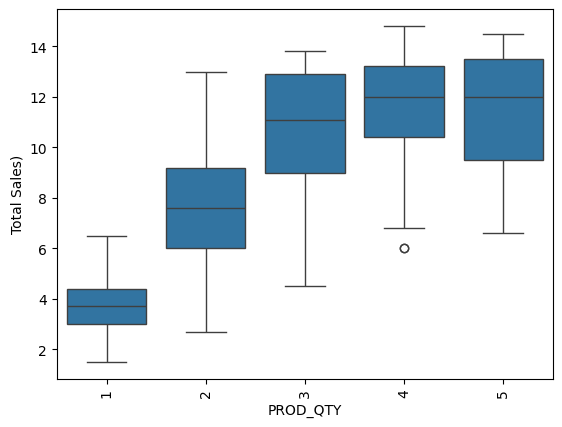

In [7]:
df_outlier_removed=remove_outlier_IQR(transaction_df.TOT_SALES)
df_outlier_removed=pd.DataFrame(df_outlier_removed)
ind_diff=transaction_df.index.difference(df_outlier_removed.index)

for i in range(0, len(ind_diff),1):
    df_final=transaction_df.drop([ind_diff[i]])
    transaction_df =df_final
    
# Visualize sales distribution across product quantities after outlier removal    
sns.boxplot(y='TOT_SALES', x='PROD_QTY',data=transaction_df)
plt.xticks(rotation=90)
plt.ylabel('Total Sales)')

In [8]:
print("Shape of dataset after treating outliers:",transaction_df.shape)

Shape of dataset after treating outliers: (264258, 8)


In [9]:
# Convert Excel integer date format to datetime standard (origin: 1899-12-30)
transaction_df['DATE'] = pd.to_datetime(
    transaction_df['DATE'], unit='D', origin='1899-12-30'
)  
transaction_df

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
5,2019-05-19,4,4074,2982,57,Old El Paso Salsa Dip Tomato Mild 300g,1,5.1
...,...,...,...,...,...,...,...,...
264831,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8
264832,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4
264833,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8
264834,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8


In [10]:
transaction_df['PROD_NAME'].value_counts()

PROD_NAME
Kettle Tortilla ChpsHny&Jlpno Chili 150g    3285
Kettle Mozzarella   Basil & Pesto 175g      3280
Tyrrells Crisps     Ched & Chives 165g      3264
Cobs Popd Swt/Chlli &Sr/Cream Chips 110g    3260
Cobs Popd Sea Salt  Chips 110g              3259
                                            ... 
Woolworths Medium   Salsa 300g              1430
RRD Pc Sea Salt     165g                    1429
French Fries Potato Chips 175g              1418
NCC Sour Cream &    Garden Chives 175g      1416
WW Crinkle Cut      Original 175g           1410
Name: count, Length: 114, dtype: int64

In [11]:
# Filter out non-chips products
transaction_df = transaction_df[transaction_df["PROD_NAME"].str.contains("Salsa")==False]

In [12]:
#  Extract numerical pack size (in grams) from product
import re
transaction_df['PACK_SIZE'] = (
    transaction_df['PROD_NAME']
    .str.extract(r'(\d+)[gG]', flags=re.IGNORECASE)[0]
    .astype(float)
)
if 'pack_size' in transaction_df.columns:
    transaction_df.drop(columns=['pack_size'], inplace=True)

print( transaction_df['PACK_SIZE'].isna().sum())

0


C:\Users\HELAL\AppData\Local\Temp\ipykernel_18456\695720523.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_df['PACK_SIZE'] = (


C:\Users\HELAL\AppData\Local\Temp\ipykernel_18456\1681946262.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_df['PACK_SIZE'] = transaction_df['PACK_SIZE'].astype(str)


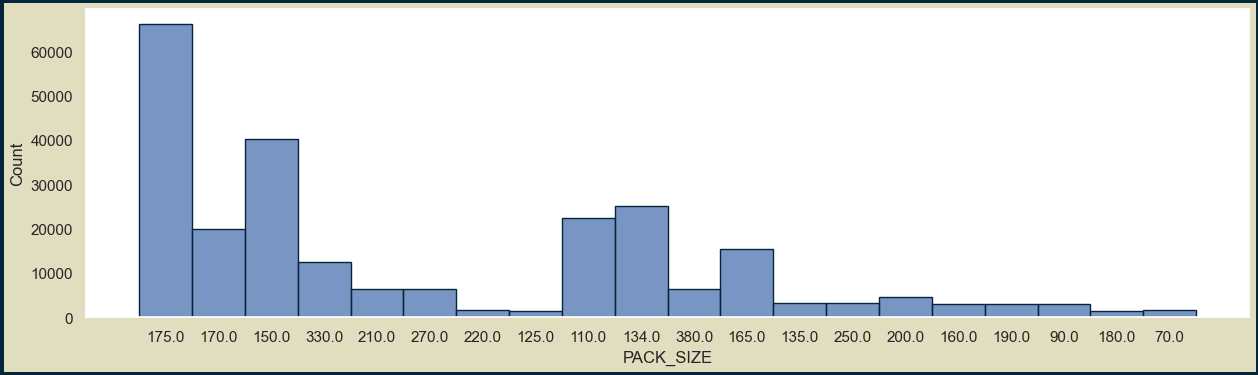

In [13]:
# Convert pack size to string for categorical grouping/plotting if needed
transaction_df['PACK_SIZE'] = transaction_df['PACK_SIZE'].astype(str)

fig = plt.figure(figsize=(15, 4), linewidth=5, edgecolor="#04253a", facecolor='#e1ddbf')
sns.set(rc={'figure.figsize': (15, 4)})
ax = sns.histplot(data=transaction_df, x="PACK_SIZE", edgecolor="#04253a")
ax.set_facecolor("#ffffff")
plt.show()

In [14]:
# Extract brand names, standardize inconsistent brand names, and count the products for each brand.
transaction_df['BRAND'] = transaction_df['PROD_NAME'].str.split().str[0]
brand_mapping = {
    'Red': 'RRD',
    'Snbts': 'Sunbites',
    'Infzns': 'Infuzions',
    'WW': 'Woolworths',
    'Smith': 'Smiths',
    'Dorito': 'Doritos',
    'Grain': 'GrnWaves',
    'NCC': 'Natural',
    'GrnWves':'GrnWaves'
}
transaction_df['BRAND'] = transaction_df['BRAND'].replace(brand_mapping)
transaction_df['BRAND'].value_counts()


C:\Users\HELAL\AppData\Local\Temp\ipykernel_18456\348765570.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_df['BRAND'] = transaction_df['PROD_NAME'].str.split().str[0]
C:\Users\HELAL\AppData\Local\Temp\ipykernel_18456\348765570.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_df['BRAND'] = transaction_df['BRAND'].replace(brand_mapping)


BRAND
Kettle        41141
Smiths        30303
Doritos       25150
Pringles      25052
RRD           16307
Infuzions     14173
Thins         14049
Woolworths    11836
Cobs           9669
Tostitos       9443
Twisties       9420
GrnWaves       7730
Natural        7453
Tyrrells       6428
Cheezels       4583
CCs            4551
Sunbites       3008
Cheetos        2926
Burger         1564
French         1418
Name: count, dtype: int64

In [15]:
Customer_df=pd.read_csv("QVI_purchase_behaviour.csv")
Customer_df

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream
...,...,...,...
72632,2370651,MIDAGE SINGLES/COUPLES,Mainstream
72633,2370701,YOUNG FAMILIES,Mainstream
72634,2370751,YOUNG FAMILIES,Premium
72635,2370961,OLDER FAMILIES,Budget


In [16]:
# Check the number of missing values in each customer-data column.
Customer_df.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [17]:
# Separate numeric and categorical columns in the customer dataset.
Data_customer_numerics_only = Customer_df.select_dtypes(include=np.number)
Data_customer_cat = set(Customer_df.columns) - set(Data_customer_numerics_only)
print("Numeric Columns:\n",list(Data_customer_numerics_only))
print("Categorical Columns:\n",Data_customer_cat)

Numeric Columns:
 ['LYLTY_CARD_NBR']
Categorical Columns:
 {'LIFESTAGE', 'PREMIUM_CUSTOMER'}


In [18]:
df4 = pd.merge(transaction_df, Customer_df)
df4

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,Kettle,MIDAGE SINGLES/COUPLES,Budget
4,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,330.0,Smiths,MIDAGE SINGLES/COUPLES,Budget
...,...,...,...,...,...,...,...,...,...,...,...,...
246199,2019-03-09,272,272319,270088,89,Kettle Sweet Chilli And Sour Cream 175g,2,10.8,175.0,Kettle,YOUNG SINGLES/COUPLES,Premium
246200,2018-08-13,272,272358,270154,74,Tostitos Splash Of Lime 175g,1,4.4,175.0,Tostitos,YOUNG SINGLES/COUPLES,Premium
246201,2018-11-06,272,272379,270187,51,Doritos Mexicana 170g,2,8.8,170.0,Doritos,YOUNG SINGLES/COUPLES,Premium
246202,2018-12-27,272,272379,270188,42,Doritos Corn Chip Mexican Jalapeno 150g,2,7.8,150.0,Doritos,YOUNG SINGLES/COUPLES,Premium


In [19]:
# Check the merged dataset for missing values.
df4.isnull().sum()

DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
PACK_SIZE           0
BRAND               0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [20]:
df4['LIFESTAGE'].value_counts()

LIFESTAGE
OLDER SINGLES/COUPLES     50677
RETIREES                  46342
OLDER FAMILIES            45042
YOUNG FAMILIES            40395
YOUNG SINGLES/COUPLES     33917
MIDAGE SINGLES/COUPLES    23342
NEW FAMILIES               6489
Name: count, dtype: int64

In [21]:
# Count the number of customers in each premium-customer category.
df4['PREMIUM_CUSTOMER'].value_counts()

PREMIUM_CUSTOMER
Mainstream    94839
Budget        86567
Premium       64798
Name: count, dtype: int64

<Figure size 1500x400 with 0 Axes>

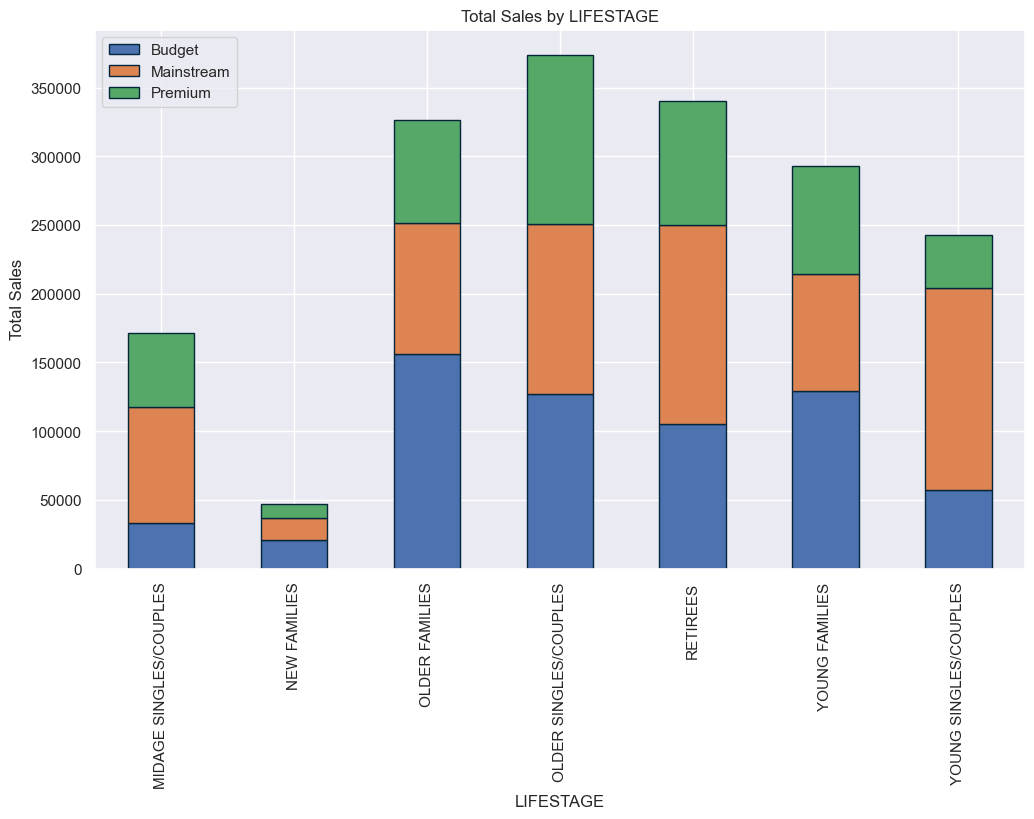

In [22]:
# Calculate total sales for each combination of life stage and customer type, then visualize the results.
df8 = pd.DataFrame(df4.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).TOT_SALES.sum())

fig = plt.figure(linewidth=5, edgecolor="#04253a", facecolor = '#e1ddbf')

df8.unstack().plot(kind = 'bar', stacked = True, figsize = (12, 7), title = 'Total Sales by LIFESTAGE' , edgecolor="#04253a")

plt.ylabel('Total Sales')
plt.legend(['Budget', 'Mainstream', 'Premium'], loc = 2)

In [23]:
# Count unique customers for each customer segment and keep the top 10 segments.
W = pd.DataFrame(df4.groupby(['PREMIUM_CUSTOMER', 'LIFESTAGE']).LYLTY_CARD_NBR.nunique())
W.rename(columns = {'LYLTY_CARD_NBR': 'Number of Customers'}, inplace = True)
W = W.sort_values(by = 'Number of Customers', ascending = False).head(10)
W

Number of Customers
PREMIUM_CUSTOMER LIFESTAGE                                 
Mainstream       YOUNG SINGLES/COUPLES                 7905
                 RETIREES                              6357
                 OLDER SINGLES/COUPLES                 4853
Budget           OLDER SINGLES/COUPLES                 4846
Premium          OLDER SINGLES/COUPLES                 4681
Budget           OLDER FAMILIES                        4606
                 RETIREES                              4382
                 YOUNG FAMILIES                        3951
Premium          RETIREES                              3811
Budget           YOUNG SINGLES/COUPLES                 3644

C:\Users\HELAL\AppData\Local\Temp\ipykernel_18456\3506140869.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(


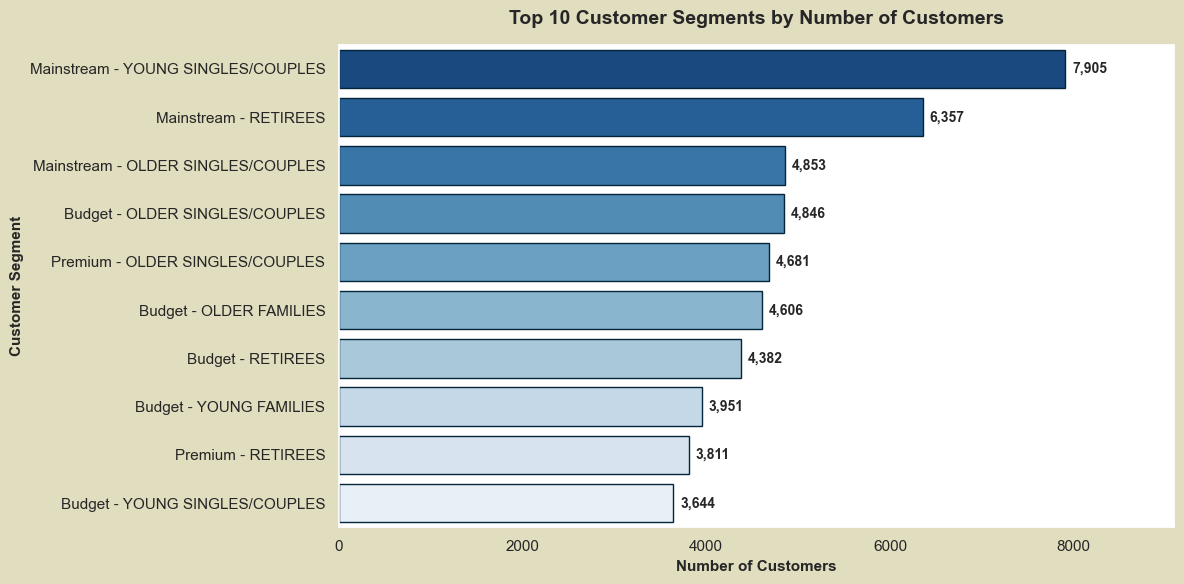

In [24]:
# Prepare the top customer segments and create a horizontal bar chart with data labels.
W_plot = W.reset_index()
W_plot['Segment'] = (
    W_plot['PREMIUM_CUSTOMER'] + ' - ' + W_plot['LIFESTAGE']
)

plt.figure(figsize=(12, 6), facecolor='#e1ddbf')
ax = plt.gca()
ax.set_facecolor('#ffffff')

bars = sns.barplot(
    data=W_plot,
    y='Segment',
    x='Number of Customers',
    palette='Blues_r',
    edgecolor='#04253a',
    ax=ax,
)

for bar in bars.patches:
    width = bar.get_width()
    ax.annotate(
        f'{int(width):,}',
        (width, bar.get_y() + bar.get_height() / 2.0),
        ha='left',
        va='center',
        fontsize=10,
        fontweight='bold',
        xytext=(5, 0),
        textcoords='offset points',
   )
plt.title(
    'Top 10 Customer Segments by Number of Customers',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Number of Customers', fontsize=11, fontweight='bold')
plt.ylabel('Customer Segment', fontsize=11, fontweight='bold')

plt.xlim(0, W_plot['Number of Customers'].max() * 1.15)
plt.tight_layout()
plt.show()

In [25]:
# Calculate total units, unique customers, and average units purchased per customer for each segment.
z = (
    df4.groupby(["PREMIUM_CUSTOMER", "LIFESTAGE"])
    .agg(
        total_units=("PROD_QTY", "sum"),
        unique_customers=("LYLTY_CARD_NBR", "nunique")
    )
)

z["Average Unit per Customer"] = (
    z["total_units"] / z["unique_customers"]
)

z= z.sort_values(
    "Average Unit per Customer",
    ascending=False
)

z.head()

,,total_units,unique_customers,Average Unit per Customer
PREMIUM_CUSTOMER,LIFESTAGE,,,
Mainstream,OLDER FAMILIES,25638,2788,9.195839
Budget,OLDER FAMILIES,41632,4606,9.038645
Premium,OLDER FAMILIES,20100,2230,9.013453
Budget,YOUNG FAMILIES,34286,3951,8.677803
Premium,YOUNG FAMILIES,20793,2397,8.674593


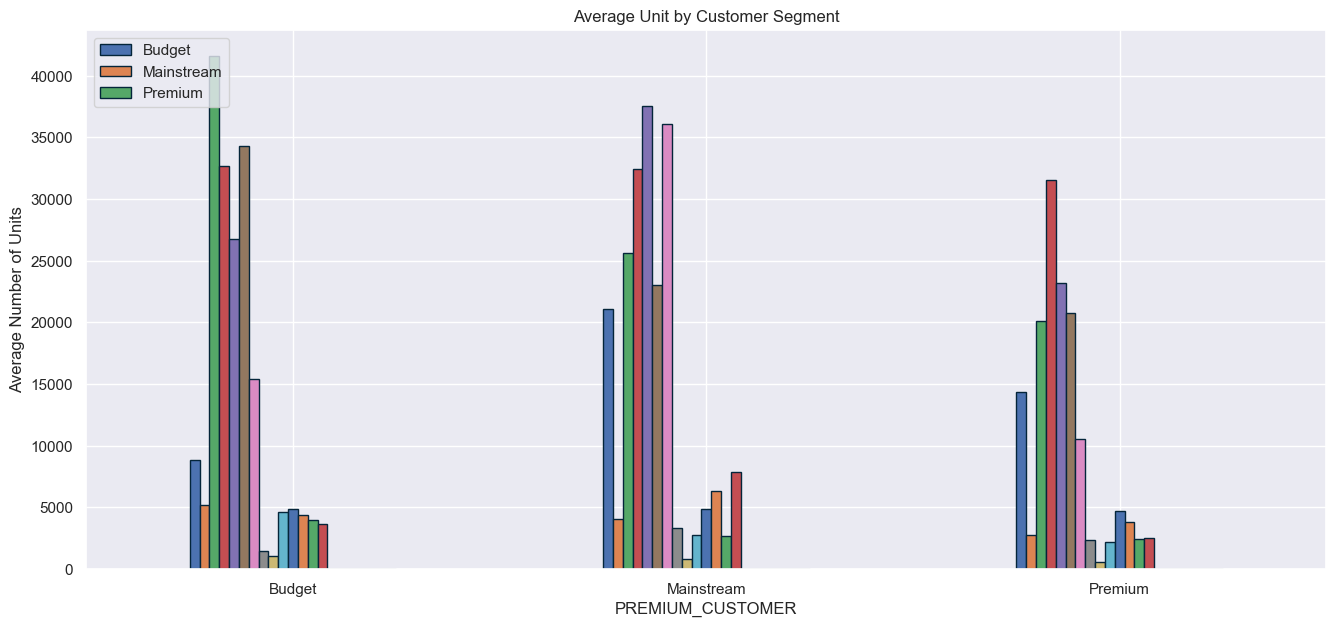

In [26]:
# Visualize the average number of units purchased by customer segment.
z.unstack().plot(kind = 'bar', figsize = (16, 7), rot = 0, title = 'Average Unit by Customer Segment',  edgecolor="#04253a")
plt.ylabel('Average Number of Units')
plt.legend(['Budget', 'Mainstream', 'Premium'], loc = 2)

In [27]:
# Save the final merged and cleaned dataset as a CSV file.
df4.to_csv('QVI_cleaned_merged_data.csv', index=False)